# The PEST++ Gaussian process library: a user's guide

This notebook shows how to use the Gaussian process regression (GPR) library in `pestpp_common`
(`GPR.h`/`GPR.cpp`) from Python, through the `pestpp-api` C API. The notebook
has three parts:

1. **Background.** What a GP is, the exact equations the library solves, and what the local approximate GP (laGP) adds.
2. **How to use it.** Fitting and predicting, kernels and hyperparameters, gradients, a 2-D example with surface plots, and local approximate GPs for large training sets.
3. **Tests: uncertainty falls as the training set grows.** A set of checks, with `assert`s, showing that adding training data reduces the predictive uncertainty. One check is exact (it holds to round-off for any data). The others are statistical, run over repeated designs.

No PEST++ control file or session is needed. A GP is an in-memory object that you fit and then predict from.


## Background

### Gaussian process regression

A Gaussian process is a probability distribution over functions. Saying
$f \sim \mathcal{GP}(0,\ \tau^2 k(\cdot,\cdot))$ means that for any finite set of inputs
$x_1, \dots, x_n$, the values $f(x_1), \dots, f(x_n)$ are jointly Gaussian with mean zero and
covariance $\tau^2 k(x_i, x_j)$. The **kernel** $k$ encodes what we believe about the function
before seeing data: how smooth it is, and how quickly two outputs stop being related as their
inputs move apart.

Regression means conditioning that prior on $n$ observed training pairs $(X, Z)$. Write
$K_{ij} = k(x_i, x_j) + g\,\delta_{ij}$ for the $n \times n$ training covariance, where the
**nugget** $g$ is a small diagonal term that stands for observation noise and keeps $K$
numerically invertible. Write $k(x)$ for the vector of kernel values between a new point $x$ and
the training points. The library follows laGP's formulation (Gramacy, 2016): the scale $\tau^2$
is integrated out under a reference prior, and the predictive distribution at $x$ is then a
Student-t with $n$ degrees of freedom, with

$$
\mu(x) = k(x)^\top K^{-1} Z,
\qquad
s^2(x) = \frac{\phi}{n}\Big(1 + g - k(x)^\top K^{-1} k(x)\Big),
\qquad
\phi = Z^\top K^{-1} Z.
$$

`predict()` returns $\mu$ as `mean`, $s^2$ as `s2` and $n$ as `df`. $s^2$ is the scale of the
t distribution, so a 95% interval is $\mu \pm t_{0.975,\,n}\, s$. For large $n$ that is close to
the familiar $\mu \pm 1.96\, s$.

Two features of $s^2$ matter for the tests in part 3:

- **The bracket depends only on the inputs.** $1 + g - k^\top K^{-1} k$ is the variance of a
  unit-scale GP after conditioning on the training inputs. It uses $X$ and never $Z$. Conditioning
  a Gaussian on more variables can never increase its variance, so with the hyperparameters held
  fixed, adding a training point can only lower this term, at every $x$. It is close to $g$ at a
  training point and close to $1 + g$ far from all of them.
- **The prefactor $\phi / n$ is data dependent.** It is the estimate of the process variance
  $\tau^2$ and moves as data arrive. So $s^2$ itself falls as data are added *on average* rather
  than at every step.

### Kernels and hyperparameters

All kernels are **isotropic**: one lengthscale $d$ is shared by every input dimension, with
$r = \lVert x - x' \rVert$.

| `kernel=` | $k(r)$ | smoothness |
|---|---|---|
| `"squared_exponential"` (default) | $\exp(-r^2/d)$ | infinitely differentiable |
| `"matern52"` | $\big(1 + \sqrt5 r/d + 5r^2/3d^2\big)\exp(-\sqrt5 r/d)$ | twice differentiable |
| `"matern32"` | $\big(1 + \sqrt3 r/d\big)\exp(-\sqrt3 r/d)$ | once differentiable |
| `"exponential"` (Matérn 1/2) | $\exp(-r/d)$ | continuous but rough |

Note that the squared exponential divides $r^2$ by $d$, while the others divide $r$ by $d$. So $d$
is a squared lengthscale for the first kernel and a lengthscale for the others, and fitted $d$
values can't be compared across kernels.

The hyperparameters $d$ and $g$ are either fixed by the user or estimated by maximising the
likelihood, with gamma priors on both. The priors and the search range come from laGP's
`darg`/`garg`. The range for $d$ runs from about half the smallest to the largest pairwise
squared distance in $X$. As in laGPy, `None` means *estimate* and a number means *hold fixed*.
The defaults are `d=None, g=1e-4`: the lengthscale is estimated and the nugget is fixed.

Things to know before fitting:

- **The prior mean is zero.** Far from the data, $\mu(x)$ returns to 0. Centre $Z$ (subtract its
  mean) before fitting and add it back after predicting. Everything below does this.
- **Isotropy means input scale matters.** Rescale the inputs to a common range, such as
  $[0, 1]$ per variable, so that one lengthscale is sensible in every direction.
- **Cost.** A full GP is $O(n^3)$ to fit, and every likelihood evaluation during estimation pays
  that again. Prediction is $O(n^2)$ per point. A few hundred points is comfortable. Thousands is
  slow, and that is what laGP is for.

### Local approximate GP (laGP)

Gramacy & Apley (2015) observed that the prediction at $x$ depends almost entirely on training
points near $x$. **laGP** therefore fits a separate small GP for each prediction point instead of
one big GP:

1. Start the local design with the `start` nearest neighbours of $x$.
2. Grow it one point at a time until it has `end` points. The next point is chosen either as the
   next-nearest neighbour (`method="nn"`), or by **Active Learning Cohn** (`method="alc"`), which
   picks the candidate that most reduces the predictive variance at $x$.
3. Fit a GP to those `end` points, with its own lengthscale, and predict at $x$.

Each prediction costs about $O(\text{end}^3)$ plus a candidate search, whatever the total $N$ is,
and the prediction points are independent, so they run in parallel (`num_threads`). ALC often
picks a few points farther out, along directions where they reduce the variance at $x$ more than
another close neighbour would. That usually gives better predictions than `nn` for the same
`end`.

### What is in the library

| Python | C API | laGPy equivalent |
|---|---|---|
| `GaussianProcess(X, Z, kernel, d, g)` | `pestpp_gp_create` | `buildGP` |
| `gp.predict(Xref, gradients=False)` | `pestpp_gp_predict` | `predict_lite` |
| `gp.d`, `gp.g`, `gp.phi`, `gp.n`, `gp.m`, `gp.kernel` | `pestpp_gp_get_info` | attributes of the GP |
| `gp_local_predict(X, Z, Xref, start, end, method, ...)` | `pestpp_gp_local_predict` | `laGP` (one point per call) |

**References**

- Rasmussen, C. E. & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press.
- Gramacy, R. B. & Apley, D. W. (2015). Local Gaussian process approximation for large computer
  experiments. *Journal of Computational and Graphical Statistics*, 24(2), 561–578.
- Gramacy, R. B. (2016). laGP: large-scale spatial modeling via local approximate Gaussian
  processes in R. *Journal of Statistical Software*, 72(1).
- Gramacy, R. B. (2020). *Surrogates: Gaussian Process Modeling, Design, and Optimization for the
  Applied Sciences*. Chapman & Hall/CRC.

## setup

In [1]:
import os
import sys
import glob
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registers the 3d projection)
from matplotlib.ticker import NullLocator, ScalarFormatter
from scipy.stats import qmc, spearmanr, t as student_t

REPO_ROOT = os.path.dirname(os.getcwd())  # this notebook lives in <repo>/examples

# Prefer the CMake Release build. A Debug build of pestpp-api (for example one copied to bin/
# for the debugger) makes GP fitting roughly 50x slower. Set PESTPP_LIB to override.
if "PESTPP_LIB" not in os.environ:
    candidates = (
        glob.glob(os.path.join(REPO_ROOT, "build", "src", "libs", "pestpp_capi", "pestpp-api.*")) +
        glob.glob(os.path.join(REPO_ROOT, "bin", "pestpp-api.*")))
    candidates = [c for c in candidates if c.endswith((".so", ".dylib", ".dll"))]
    if candidates:
        os.environ["PESTPP_LIB"] = candidates[0]

sys.path.insert(0, os.path.join(REPO_ROOT, "python"))
from pestpp import GaussianProcess, gp_local_predict, PestppError, api_info

info = api_info()
print("pestpp-api :", info["library_path"])
print("api version:", info["api_version"], "| pest++", info["pestpp_version"])

# fixed categorical order: blue, orange, aqua, yellow, magenta, green, violet, red
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "axes.prop_cycle": plt.cycler(color=SERIES),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "0.9", "grid.linewidth": 0.8,
    "lines.linewidth": 2, "legend.frameon": False, "figure.dpi": 110,
})
BAND = "#86b6ef"   # light step of the blue ramp, for uncertainty bands

pestpp-api : /Users/rqmacasieb/Documents/Github/pestpp/build/src/libs/pestpp_capi/pestpp-api.dylib
api version: 0.7.0 | pest++ 6.0.0a2


### test functions

Two cheap analytic functions, so the true value is known everywhere:

- **Forrester (1-D)**, $f(x) = (6x - 2)^2 \sin(12x - 4)$ on $[0, 1]$. It has a local minimum, a
  global minimum and a steep rise, which is plenty of structure for one dimension.
- **Branin (2-D)**, the usual test function, with both inputs rescaled to $[0, 1]$ to follow the
  "rescale inputs" advice above.

`fit()` and `predict()` wrap the library calls with the output centring from the background
section.

In [2]:
def forrester(x):
    x = np.asarray(x, dtype=float).ravel()
    return (6 * x - 2) ** 2 * np.sin(12 * x - 4)


def branin(X):
    """Branin on [0, 1]^2 (x1 in [-5, 10] and x2 in [0, 15] after rescaling)"""
    x1, x2 = 15 * X[:, 0] - 5, 15 * X[:, 1]
    return ((x2 - 5.1 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
            + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def fit(X, Z, **kw):
    """fit a GP to centred outputs; the offset is kept on the object for predict()"""
    Z = np.asarray(Z, dtype=float)
    gp = GaussianProcess(X, Z - Z.mean(), **kw)
    gp.z_offset = Z.mean()
    return gp


def predict(gp, Xref, **kw):
    p = gp.predict(Xref, **kw)
    p["mean"] = p["mean"] + gp.z_offset
    p["sd"] = np.sqrt(p["s2"])
    return p


def interval95(p):
    """half-width of the 95% Student-t predictive interval"""
    return student_t.ppf(0.975, p["df"]) * p["sd"]


# a dense grid for the 1-D plots, and a 40 x 40 grid over [0, 1]^2 as the 2-D test set
x_grid = np.linspace(0, 1, 400).reshape(-1, 1)
f_grid = forrester(x_grid)
g = np.linspace(0, 1, 40)
X_test = np.column_stack([a.ravel() for a in np.meshgrid(g, g)])
Z_test = branin(X_test)
print("2-D test set:", X_test.shape, " Branin range [{0:.1f}, {1:.1f}]".format(Z_test.min(), Z_test.max()))

2-D test set: (1600, 2)  Branin range [0.4, 308.1]


# Part 2: using the library

## 2.1 quick start

Fit on 7 points, predict on a grid, and plot the mean and the 95% interval. `X` is always
`(n, m)`, one row per point. A 1-D array is read as `n` points in one dimension. `Z` is `(n,)`.

In [3]:
X7 = np.linspace(0.05, 0.95, 7).reshape(-1, 1)
Z7 = forrester(X7)

gp = fit(X7, Z7)                    # d estimated by maximum likelihood, g fixed at 1e-4
print(gp)
print("fitted lengthscale d = {0:.4g}, nugget g = {1:.1e}, phi = {2:.4g}".format(gp.d, gp.g, gp.phi))

p = predict(gp, x_grid)
print("keys returned by predict():", sorted(gp.predict(x_grid[:1]).keys()))
print("mean shape", p["mean"].shape, "| s2 shape", p["s2"].shape, "| df", p["df"])

GaussianProcess(n=7, m=1, kernel='squared_exponential', d=0.01125, g=0.0001)
fitted lengthscale d = 0.01125, nugget g = 1.0e-04, phi = 193.2
keys returned by predict(): ['df', 'mean', 's2']
mean shape (400,) | s2 shape (400,) | df 7


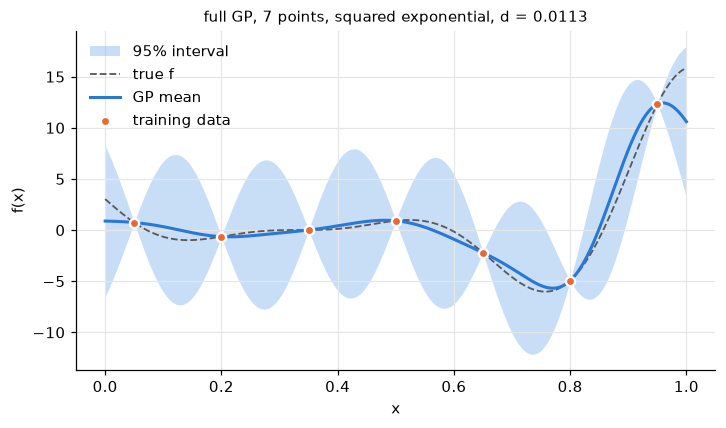

In [4]:
def plot_fit(ax, Xtr, Ztr, p, title=None, truth=True):
    x = x_grid.ravel()
    hw = interval95(p)
    ax.fill_between(x, p["mean"] - hw, p["mean"] + hw, color=BAND, alpha=0.45, lw=0, label="95% interval")
    if truth:
        ax.plot(x, f_grid, color="0.35", lw=1.2, ls="--", label="true f")
    ax.plot(x, p["mean"], color=SERIES[0], label="GP mean")
    ax.scatter(np.ravel(Xtr), Ztr, s=36, color=SERIES[1], zorder=5, edgecolor="white", lw=1.5,
               label="training data")
    ax.set_xlabel("x")
    if title:
        ax.set_title(title, fontsize=10)


fig, ax = plt.subplots(figsize=(7.5, 4))
plot_fit(ax, X7, Z7, p, "full GP, 7 points, squared exponential, d = {0:.3g}".format(gp.d))
ax.set_ylabel("f(x)")
ax.legend(loc="upper left")
plt.show()

The interval pinches to almost nothing at each training point, where the bracket in $s^2$ is about
$g$, and opens up in the gaps. Its width in a gap depends on how far that gap is from the data and
on $\phi/n$. It doesn't depend on how wrong the mean happens to be there. The model's uncertainty
comes from where the data are, not from any knowledge of the true error.

A GP is released when the Python object is garbage collected. To release it at a known point,
call `gp.destroy()` or use `with GaussianProcess(...) as gp:`.

## 2.2 kernels

The same 7 points, fitted with each kernel. Rougher kernels (toward `exponential`) give means that
are less smooth between points and variance that rises faster away from the data.

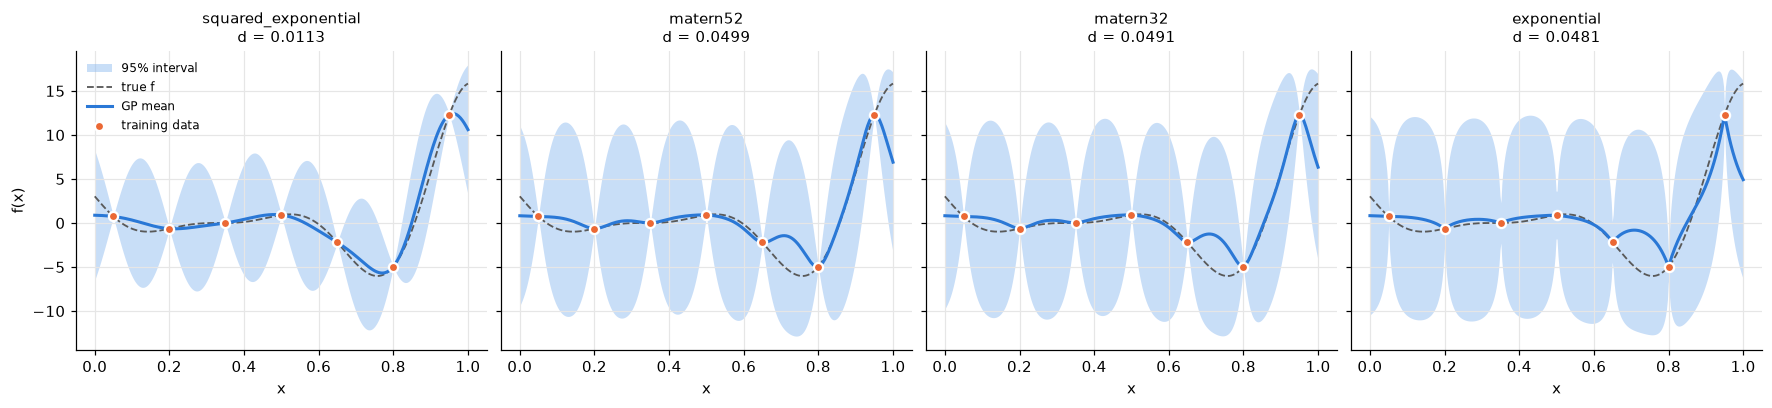

,d,RMSE vs truth,mean sd
kernel,,,
squared_exponential,0.0113,1.0111,1.9408
matern52,0.0499,1.6462,3.1808
matern32,0.0491,1.7701,3.3939
exponential,0.0481,2.2342,4.0674


In [5]:
KERNELS = ["squared_exponential", "matern52", "matern32", "exponential"]
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=True, constrained_layout=True)
rows = []
for ax, k in zip(axes, KERNELS):
    gk = fit(X7, Z7, kernel=k)
    pk = predict(gk, x_grid)
    plot_fit(ax, X7, Z7, pk, "{0}\nd = {1:.3g}".format(k, gk.d))
    rows.append({"kernel": k, "d": gk.d,
                 "RMSE vs truth": np.sqrt(np.mean((pk["mean"] - f_grid) ** 2)),
                 "mean sd": pk["sd"].mean()})
axes[0].set_ylabel("f(x)")
axes[0].legend(loc="upper left", fontsize=8)
plt.show()
pd.DataFrame(rows).set_index("kernel").round(4)

## 2.3 fixed vs estimated hyperparameters, and the nugget

Passing a number holds a hyperparameter fixed. That is useful for testing, for reusing a
lengthscale from an earlier fit, or for encoding prior knowledge. The left panels show that a
too-small lengthscale makes the GP revert to its mean between points and gives wide intervals. A
too-large one gives an overconfident, overly smooth fit.

The nugget sets how closely the GP must pass through the data. With noisy observations, the
default `g=1e-4` forces the mean through every noisy point. A larger fixed nugget smooths through
the noise instead. The right-hand panels show both.

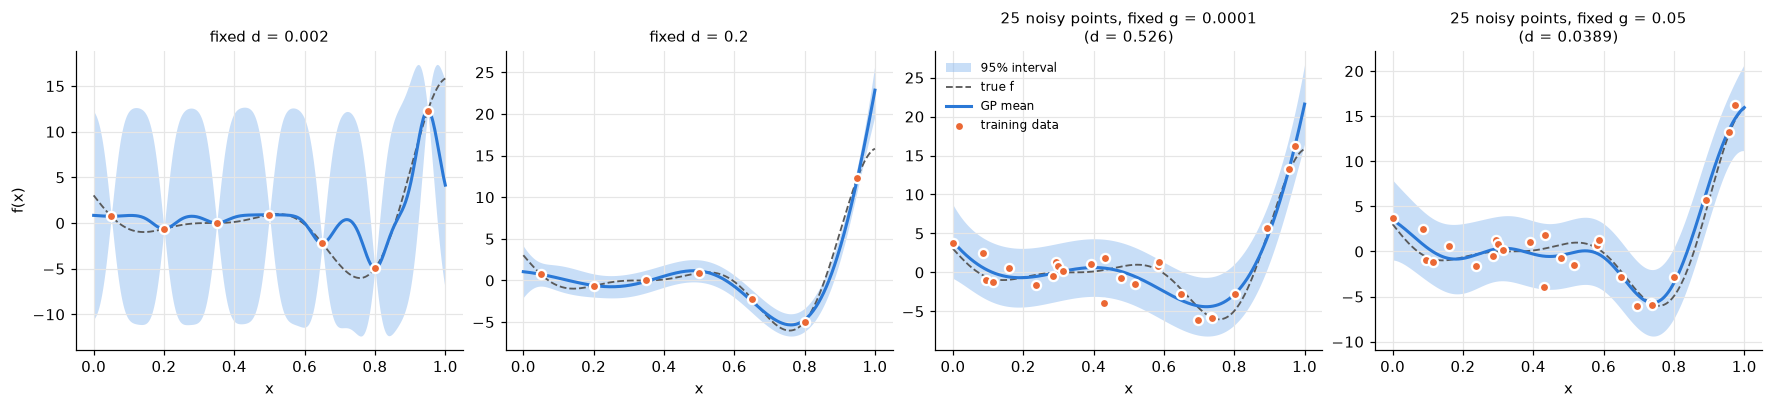

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), constrained_layout=True)
for ax, d in zip(axes[:2], [0.002, 0.2]):
    plot_fit(ax, X7, Z7, predict(fit(X7, Z7, d=d), x_grid), "fixed d = {0}".format(d))
axes[0].set_ylabel("f(x)")

rng = np.random.default_rng(3)
Xn = np.sort(rng.random(25)).reshape(-1, 1)
Zn = forrester(Xn) + rng.normal(0, 1.5, Xn.shape[0])      # noise sd 1.5
for ax, g_ in zip(axes[2:], [1e-4, 0.05]):
    gn = fit(Xn, Zn, g=g_)
    plot_fit(ax, Xn, Zn, predict(gn, x_grid), "25 noisy points, fixed g = {0:g}\n(d = {1:.3g})".format(g_, gn.d))
axes[2].legend(loc="upper left", fontsize=8)
plt.show()

**The nugget can't be estimated yet.** `g=None` (estimate the nugget, alone or jointly with `d`)
currently fails inside `GPR.cpp`. This is a known, parked issue. The failure is contained. It comes back as a
`PestppError`, and the same `except` catches every other invalid input:

In [7]:
for label, call in [
        ("estimate the nugget (g=None)", lambda: GaussianProcess(X7, Z7, g=None)),
        ("NaN in the training outputs", lambda: GaussianProcess(X7, np.r_[Z7[:-1], np.nan])),
        ("unknown kernel", lambda: GaussianProcess(X7, Z7, kernel=9)),
        ("wrong dimension at predict", lambda: gp.predict(np.zeros((3, 2)))),
        ("unknown local method", lambda: gp_local_predict(X7, Z7, x_grid[:2], method="alcx"))]:
    try:
        call()
        print("{0:32s} -> no error".format(label))
    except (PestppError, ValueError) as e:
        print("{0:32s} -> {1}: {2}".format(label, type(e).__name__, str(e)[:95]))

estimate the nugget (g=None)     -> PestppError: pestpp_gp_create: GP::mle(): dK required for nugget Newton MLE (status 1)
NaN in the training outputs      -> PestppError: pestpp_gp_create: Z contains NaN or infinite values (status 4)
unknown kernel                   -> ValueError: unknown GP kernel 9; expected 0-3 or a kernel name
wrong dimension at predict       -> PestppError: pestpp_gp_predict: prediction points have 2 dimensions but the GP was fitted on 1 (status 4)
unknown local method             -> PestppError: pestpp_gp_local_predict: unknown local design method 'alcx'; expected "alc" or "nn" (status 4)


## 2.4 gradients

`predict(Xref, gradients=True)` also returns the analytic gradients `dmean` and `ds2`, each of
shape `(nref, m)`. They cost little beyond the prediction itself, and they are what a
gradient-based search on the surrogate needs. For example, you can step downhill on `mean`, or
uphill on `s2` to find where the model is least certain. The check below compares them with
central finite differences.

dmean shape (400, 1)
max |dmean - finite difference| / max|dmean| = 6.9e-10
max |ds2   - finite difference| / max|ds2|   = 1.6e-09


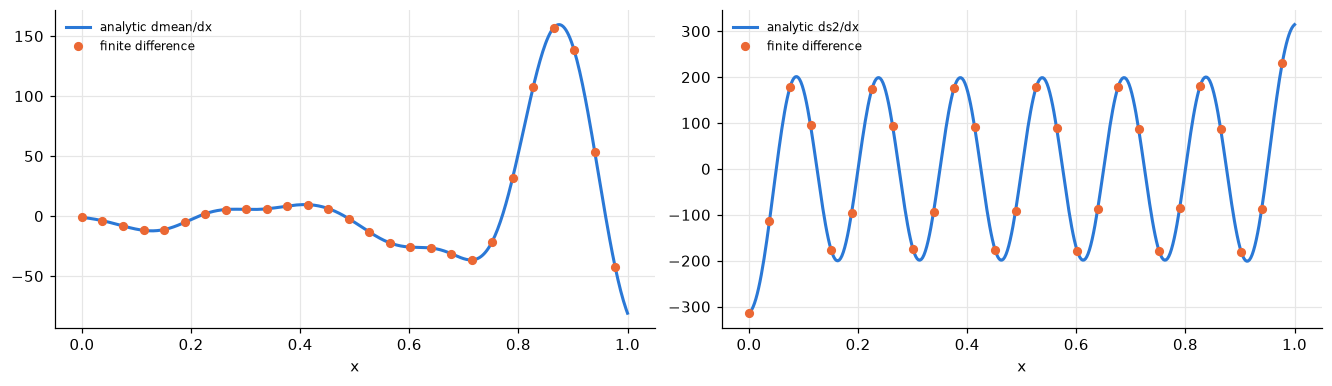

In [8]:
pg = gp.predict(x_grid, gradients=True)
h = 1e-6
fd_mean = (gp.predict(x_grid + h)["mean"] - gp.predict(x_grid - h)["mean"]) / (2 * h)
fd_s2 = (gp.predict(x_grid + h)["s2"] - gp.predict(x_grid - h)["s2"]) / (2 * h)
print("dmean shape", pg["dmean"].shape)
print("max |dmean - finite difference| / max|dmean| = {0:.1e}".format(
    np.abs(pg["dmean"][:, 0] - fd_mean).max() / np.abs(pg["dmean"]).max()))
print("max |ds2   - finite difference| / max|ds2|   = {0:.1e}".format(
    np.abs(pg["ds2"][:, 0] - fd_s2).max() / np.abs(pg["ds2"]).max()))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4), constrained_layout=True)
axes[0].plot(x_grid, pg["dmean"][:, 0], label="analytic dmean/dx")
axes[0].plot(x_grid[::15], fd_mean[::15], "o", ms=5, color=SERIES[1], label="finite difference")
axes[1].plot(x_grid, pg["ds2"][:, 0], label="analytic ds2/dx")
axes[1].plot(x_grid[::15], fd_s2[::15], "o", ms=5, color=SERIES[1], label="finite difference")
for ax in axes:
    ax.set_xlabel("x")
    ax.legend(fontsize=8)
plt.show()

The check above only shows that the library differentiates **its own** mean correctly. A separate
question is how close that slope is to the slope of the **true function**. Forrester has a
closed-form derivative:

$$f'(x) = 12(6x-2)\sin(12x-4) + 12(6x-2)^2\cos(12x-4)$$

The left panel compares it with `dmean` from the 7-point quick-start GP. The right panel repeats
the comparison for nested designs of 5, 9, 17 and 33 points. There is no true counterpart for
`ds2`: it is the slope of the model's own variance, not a property of $f$. The library doesn't
return the uncertainty of the gradient itself, so no band is drawn.

max |f'(x) - finite difference of f| / max|f'| = 4.7e-11


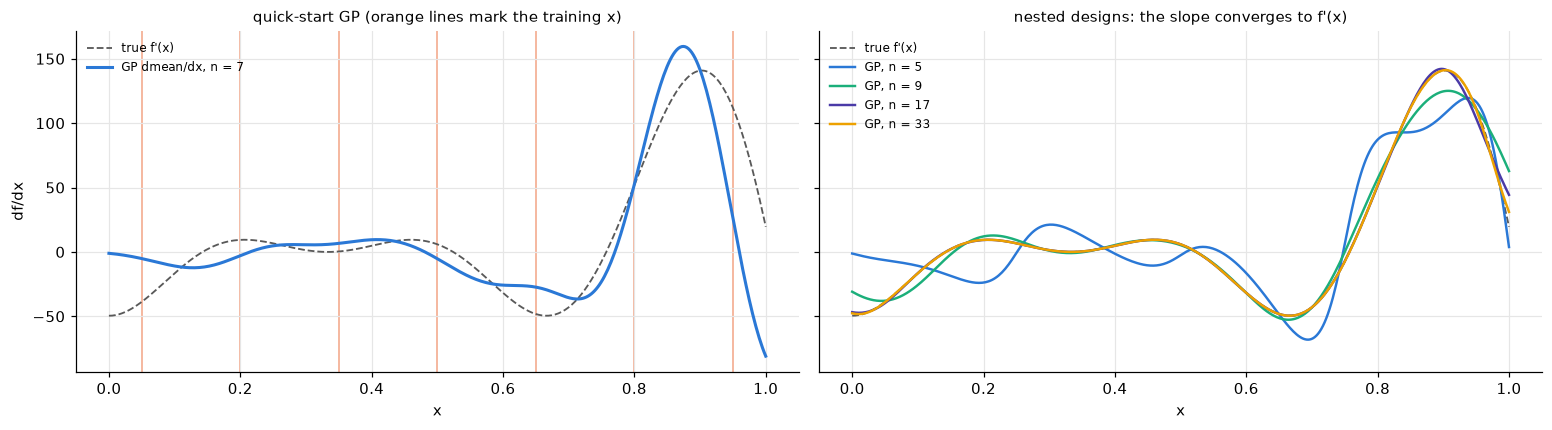

gradient RMSE over the grid (f' ranges from -50 to 141):


,design,gradient RMSE
n,,
7,quick start,30.441
5,"nested, matern52",21.316
9,"nested, matern52",7.918
17,"nested, matern52",2.741
33,"nested, matern52",0.980


In [9]:
def forrester_grad(x):
    x = np.asarray(x, dtype=float).ravel()
    return 12 * (6 * x - 2) * np.sin(12 * x - 4) + 12 * (6 * x - 2) ** 2 * np.cos(12 * x - 4)


df_true = forrester_grad(x_grid)

# the analytic derivative itself, checked against a finite difference of the true function
fd_true = (forrester(x_grid + h) - forrester(x_grid - h)) / (2 * h)
print("max |f'(x) - finite difference of f| / max|f'| = {0:.1e}".format(
    np.abs(df_true - fd_true).max() / np.abs(df_true).max()))

fig, axes = plt.subplots(1, 2, figsize=(14, 3.8), sharey=True, constrained_layout=True)
ax = axes[0]
ax.plot(x_grid, df_true, color="0.35", lw=1.2, ls="--", label="true f'(x)")
ax.plot(x_grid, pg["dmean"][:, 0], color=SERIES[0], label="GP dmean/dx, n = 7")
for xi in X7.ravel():
    ax.axvline(xi, color=SERIES[1], lw=1, alpha=0.6, zorder=1)
ax.set_title("quick-start GP (orange lines mark the training x)", fontsize=10)
ax.set_xlabel("x")
ax.set_ylabel("df/dx")
ax.legend(fontsize=8, loc="upper left")

rows = [{"n": 7, "design": "quick start", "gradient RMSE": np.sqrt(np.mean((pg["dmean"][:, 0] - df_true) ** 2))}]
ax = axes[1]
ax.plot(x_grid, df_true, color="0.35", lw=1.2, ls="--", label="true f'(x)")
for j, n in enumerate([5, 9, 17, 33]):
    Xg = np.linspace(0, 1, n).reshape(-1, 1)          # each is a subset of the next
    dm = fit(Xg, forrester(Xg), kernel="matern52").predict(x_grid, gradients=True)["dmean"][:, 0]
    ax.plot(x_grid, dm, color=SERIES[[0, 2, 6, 3][j]], lw=1.6, label="GP, n = {0}".format(n))
    rows.append({"n": n, "design": "nested, matern52", "gradient RMSE": np.sqrt(np.mean((dm - df_true) ** 2))})
ax.set_title("nested designs: the slope converges to f'(x)", fontsize=10)
ax.set_xlabel("x")
ax.legend(fontsize=8, loc="upper left")
plt.show()

print("gradient RMSE over the grid (f' ranges from {0:.0f} to {1:.0f}):".format(df_true.min(), df_true.max()))
pd.DataFrame(rows).set_index("n").round(3)

## 2.5 a 2-D example: Branin

Nothing changes in the calls for more than one input. `X` becomes `(n, 2)`, and the prediction
points are the rows of a flattened grid. Here the GP is fitted to 30 Sobol points and predicted on
an 80 × 80 grid. The first figure compares the true surface with the emulated one. The second
maps the true function, the GP mean, the actual error and the predictive sd.

GaussianProcess(n=30, m=2, kernel='matern52', d=0.430185, g=0.0001)
RMSE over the grid 17.18, mean sd 6.10 (Branin range 0 to 308)


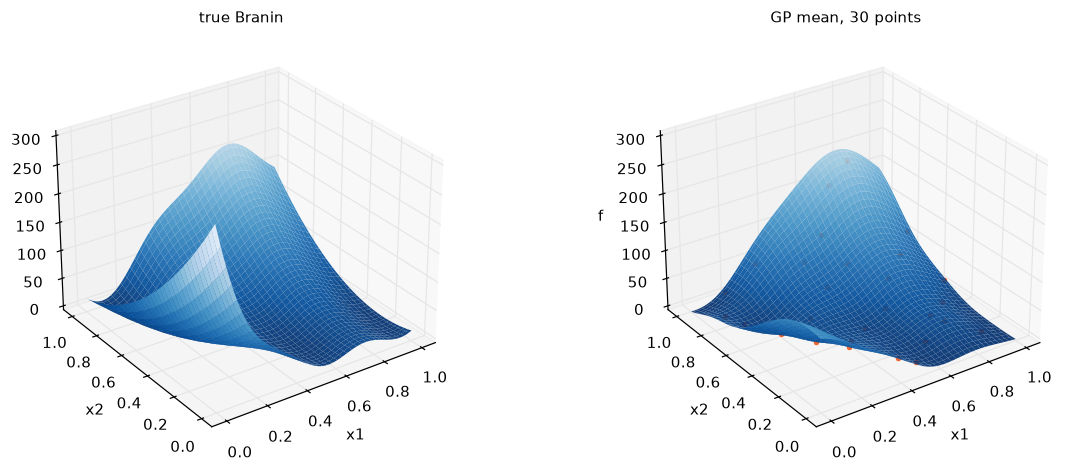

In [10]:
g80 = np.linspace(0, 1, 80)
G1, G2 = np.meshgrid(g80, g80)
X_plot = np.column_stack([G1.ravel(), G2.ravel()])      # (6400, 2)
F_plot = branin(X_plot).reshape(G1.shape)

X30 = qmc.Sobol(d=2, scramble=True, seed=4).random(32)[:30]
Z30 = branin(X30)
gp2 = fit(X30, Z30, kernel="matern52")
p2 = predict(gp2, X_plot)
M_plot, S_plot = p2["mean"].reshape(G1.shape), p2["sd"].reshape(G1.shape)
print(gp2)
print("RMSE over the grid {0:.2f}, mean sd {1:.2f} (Branin range {2:.0f} to {3:.0f})".format(
    np.sqrt(np.mean((M_plot - F_plot) ** 2)), S_plot.mean(), F_plot.min(), F_plot.max()))

zlim = (min(F_plot.min(), M_plot.min()), max(F_plot.max(), M_plot.max()))
vnorm = Normalize(*zlim)
fig = plt.figure(figsize=(13, 5))
for j, (Zs, title) in enumerate([(F_plot, "true Branin"), (M_plot, "GP mean, 30 points")]):
    ax = fig.add_subplot(1, 2, j + 1, projection="3d")
    ax.plot_surface(G1, G2, Zs, cmap="Blues_r", norm=vnorm, rstride=2, cstride=2,
                    linewidth=0, antialiased=True, alpha=0.95)
    if j == 1:
        ax.scatter(X30[:, 0], X30[:, 1], Z30, color=SERIES[1], s=18, depthshade=False,
                   edgecolor="white", linewidth=0.5)
    ax.set_zlim(*zlim)
    ax.set_xlabel("x1"); ax.set_ylabel("x2"); ax.set_zlabel("f")
    ax.view_init(elev=28, azim=-125)
    ax.set_title(title, fontsize=10)
plt.show()

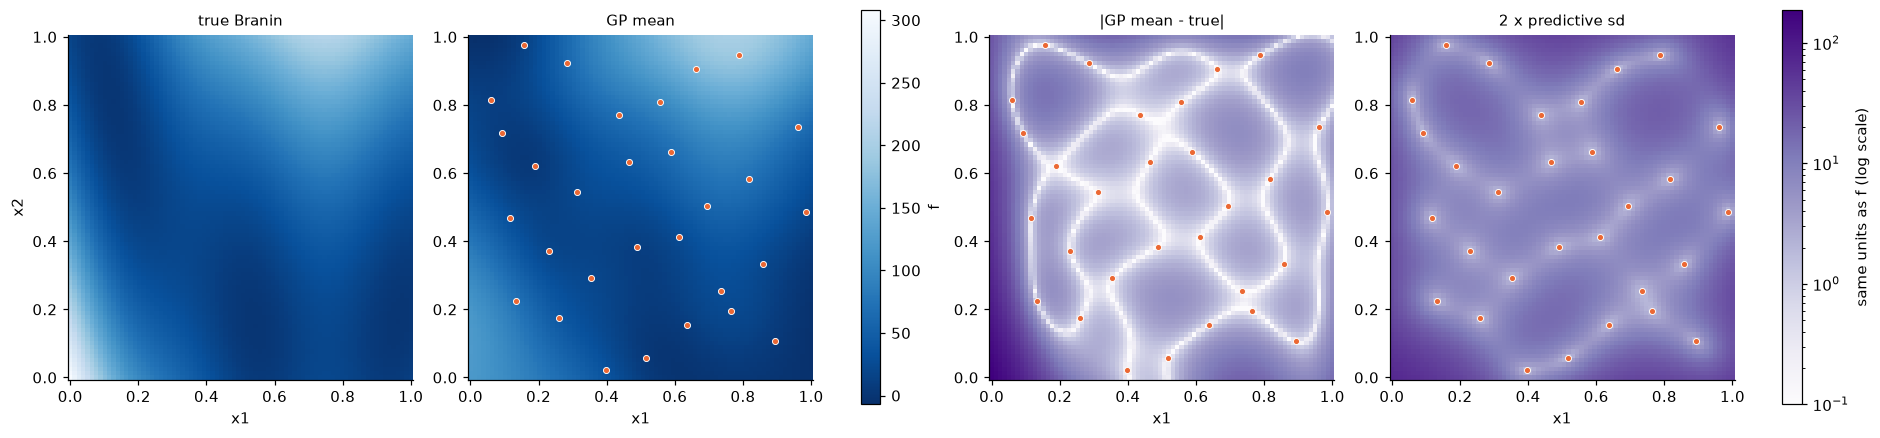

In [11]:
def map_panel(ax, V, title, cmap, norm, pts=None, label=None):
    im = ax.pcolormesh(G1, G2, V, cmap=cmap, norm=norm, shading="auto")
    if pts is not None:
        ax.scatter(pts[:, 0], pts[:, 1], s=16, color=SERIES[1], edgecolor="white", lw=0.6)
    ax.set_title(title, fontsize=10)
    ax.set_aspect("equal"); ax.grid(False)
    ax.set_xlabel("x1")
    return im


err_norm = LogNorm(0.1, max(np.abs(M_plot - F_plot).max(), (2 * S_plot).max()))
fig, axes = plt.subplots(1, 4, figsize=(17, 4.3), constrained_layout=True)
im = map_panel(axes[0], F_plot, "true Branin", "Blues_r", vnorm)
map_panel(axes[1], M_plot, "GP mean", "Blues_r", vnorm, X30)
fig.colorbar(im, ax=axes[:2], shrink=0.85, label="f")
im = map_panel(axes[2], np.abs(M_plot - F_plot), "|GP mean - true|", "Purples", err_norm, X30)
map_panel(axes[3], 2 * S_plot, "2 x predictive sd", "Purples", err_norm, X30)
fig.colorbar(im, ax=axes[2:], shrink=0.85, label="same units as f (log scale)")
axes[0].set_ylabel("x2")
plt.show()

The actual error and the predicted uncertainty share a logarithmic colour scale, so they can be
compared directly. The GP can't see its own error, but its uncertainty is highest in the same
places: the edges, the corners and the gaps between points. Both drop sharply near each training
point. The largest error is in the steep corner near $(0, 0)$, where Branin rises to about 300 and
the nearest training point is some distance away. The thin white curves in the error map are not special: they are
where the GP mean crosses the true surface, so the error changes sign and passes through zero.
The sd has no such curves. It measures how far a point is from the data, not the sign of the
error.

## 2.6 local approximate GP for large training sets

A full GP on a few thousand points is slow: the fit repeats an $O(n^3)$ factorisation at every
likelihood evaluation. `gp_local_predict` takes the whole training set and all the prediction
points in one call. It fits one small GP per prediction point and can run them on several
threads. It is stateless: there is no object to keep, and each call rebuilds the local designs.

Here the training set is 1,000 Latin hypercube points on Branin, and there are 500 prediction
points.

In [12]:
N_BIG = 1000
X_big = qmc.LatinHypercube(d=2, seed=5).random(N_BIG)
Z_big = branin(X_big)
X_q = np.random.default_rng(0).random((500, 2))
Z_q = branin(X_q)
z0 = Z_big.mean()

rows = []
t0 = time.perf_counter()
gp_big = fit(X_big, Z_big)
p_full = predict(gp_big, X_q)
rows.append({"method": "full GP (n = {0})".format(N_BIG), "seconds": time.perf_counter() - t0,
             "RMSE": np.sqrt(np.mean((p_full["mean"] - Z_q) ** 2)), "mean sd": p_full["sd"].mean()})

for meth in ("nn", "alc"):
    for nt in (1, 8):
        t0 = time.perf_counter()
        pl = gp_local_predict(X_big, Z_big - z0, X_q, start=6, end=30, method=meth, num_threads=nt)
        dt = time.perf_counter() - t0
        rows.append({"method": "laGP {0}, end = 30, {1} thread(s)".format(meth, nt), "seconds": dt,
                     "RMSE": np.sqrt(np.mean((pl["mean"] + z0 - Z_q) ** 2)),
                     "mean sd": np.sqrt(pl["s2"]).mean()})
with pd.option_context("display.float_format", "{:.4g}".format):
    display(pd.DataFrame(rows).set_index("method"))
print("Branin output range is about 0 to 300, so all of these errors are small")

,seconds,RMSE,mean sd
method,,,
full GP (n = 1000),15.31,0.06494,0.1954
"laGP nn, end = 30, 1 thread(s)",0.3703,0.1128,0.2454
"laGP nn, end = 30, 8 thread(s)",0.06116,0.1128,0.2454
"laGP alc, end = 30, 1 thread(s)",1.682,0.08514,0.3496
"laGP alc, end = 30, 8 thread(s)",0.2325,0.08514,0.3496


Branin output range is about 0 to 300, so all of these errors are small


On a smooth 2-D function like Branin, the full GP is the most accurate, because it uses every
point. laGP gives up a little accuracy for a large saving in time. The saving grows with $N$,
because the local cost doesn't depend on $N$. With the same `end`, `alc` is usually more accurate
than `nn`, because it spends part of its budget on points that inform the prediction beyond the
nearest cluster.

---

# Part 3: tests — uncertainty falls as the training set grows

These are the tests:

| test | what it checks | kind |
|---|---|---|
| **A** | With $d$, $g$ fixed and nested designs, the bracket $1 + g - k^\top K^{-1} k$ never increases at any test point as points are added, for all four kernels | exact (round-off tolerance) |
| **B** | With hyperparameters estimated as usual, the median predictive sd over 20 random designs falls at every step from n = 8 to n = 256, and the prediction error falls with it | statistical |
| **C** | The 95% intervals remain calibrated as n grows: coverage stays near or above 95% while the intervals shrink | statistical |
| **D** | For laGP with a fixed local design size, the predictive sd falls as the total training set N grows, because each local design gets denser | statistical |

## 3.0 what it looks like, in 1-D

Nested designs: every set contains the one before it, plus new points in the gaps.

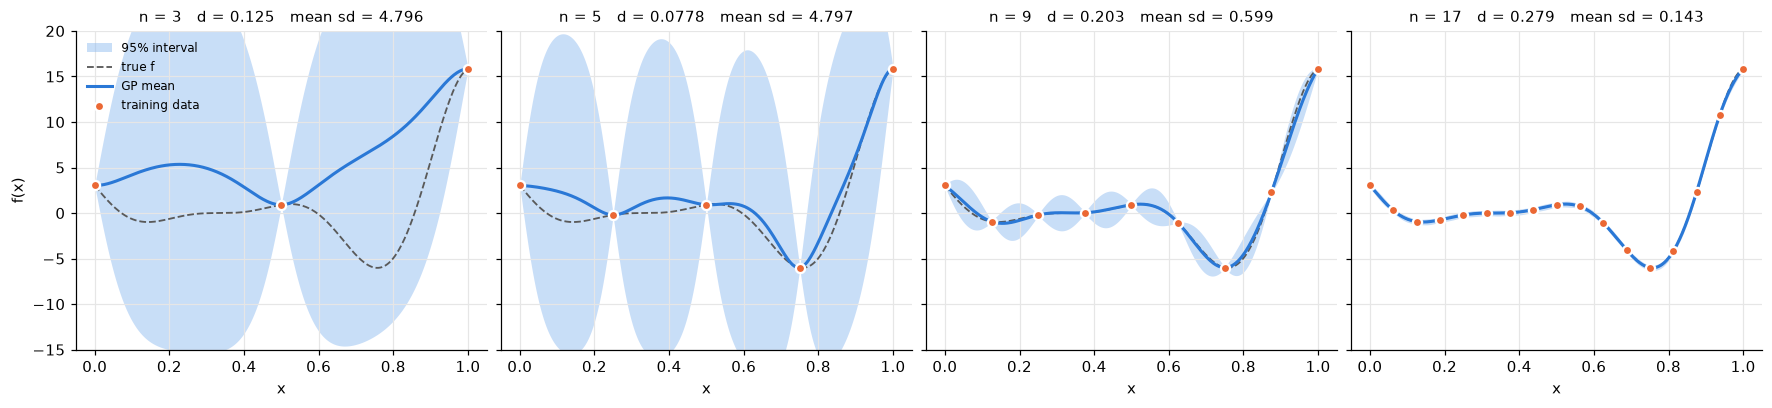

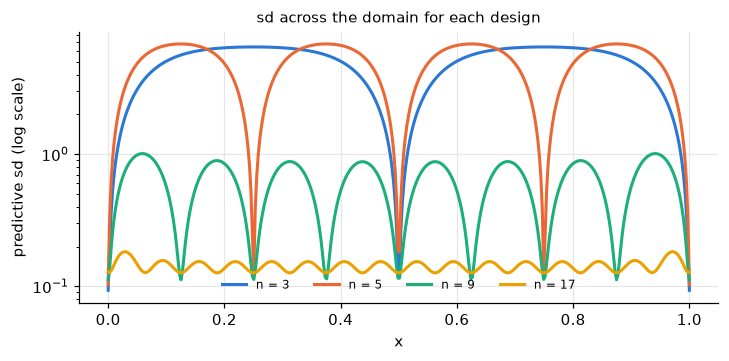

In [13]:
RESULTS = []

NS_1D = [3, 5, 9, 17]
fig, axes = plt.subplots(1, len(NS_1D), figsize=(16, 3.6), sharey=True, constrained_layout=True)
sd_1d = {}
for ax, n in zip(axes, NS_1D):
    Xn1 = np.linspace(0, 1, n).reshape(-1, 1)   # each is a subset of the next
    gpn = fit(Xn1, forrester(Xn1), kernel="matern52")
    pn = predict(gpn, x_grid)
    sd_1d[n] = pn["sd"]
    plot_fit(ax, Xn1, forrester(Xn1), pn, "n = {0}   d = {1:.3g}   mean sd = {2:.3f}".format(n, gpn.d, pn["sd"].mean()))
axes[0].set_ylabel("f(x)")
axes[0].legend(loc="upper left", fontsize=8)
axes[0].set_ylim(-15, 20)
plt.show()

fig, ax = plt.subplots(figsize=(7.5, 3.2))
for n in NS_1D:
    ax.semilogy(x_grid, sd_1d[n], label="n = {0}".format(n))
ax.set_xlabel("x")
ax.set_ylabel("predictive sd (log scale)")
ax.legend(ncol=4, fontsize=8)
ax.set_title("sd across the domain for each design", fontsize=10)
plt.show()

The overall trend is clear, but look at n = 3 and n = 5. Their mean sd is essentially the same,
even though n = 5 contains the n = 3 design. With two new points, the refit picked a shorter
lengthscale and $\phi$ roughly doubled: the new points revealed that the function varies more
than three points suggested. With re-estimated hyperparameters, adding data can leave the
predictive sd flat, or even raise it, at one step. Tests A and B separate the two effects: A
holds the hyperparameters fixed and checks the exact property, and B checks the trend when the
hyperparameters are re-estimated.

## 3.1 what it looks like, in 2-D: emulated vs true

The same 2-D Branin problem, with nested Sobol designs of 8, 16, 32, 64 and 128 points (each
design is the first $n$ points of one sequence). Each design is fitted with the defaults, using
the Matérn 5/2 kernel with $d$ estimated.

The first figure shows the GP mean and the predictive sd on the grid for each design. The sd
colour scale is logarithmic and shared across the panels.

The second figure is the main one. For 200 random check points, it plots the **emulated value
against the true value**, with a vertical bar for the 95% predictive interval at each point. A
perfect emulator would put every point on the 1:1 line with no bar. Points whose interval misses
the true value are drawn in orange.

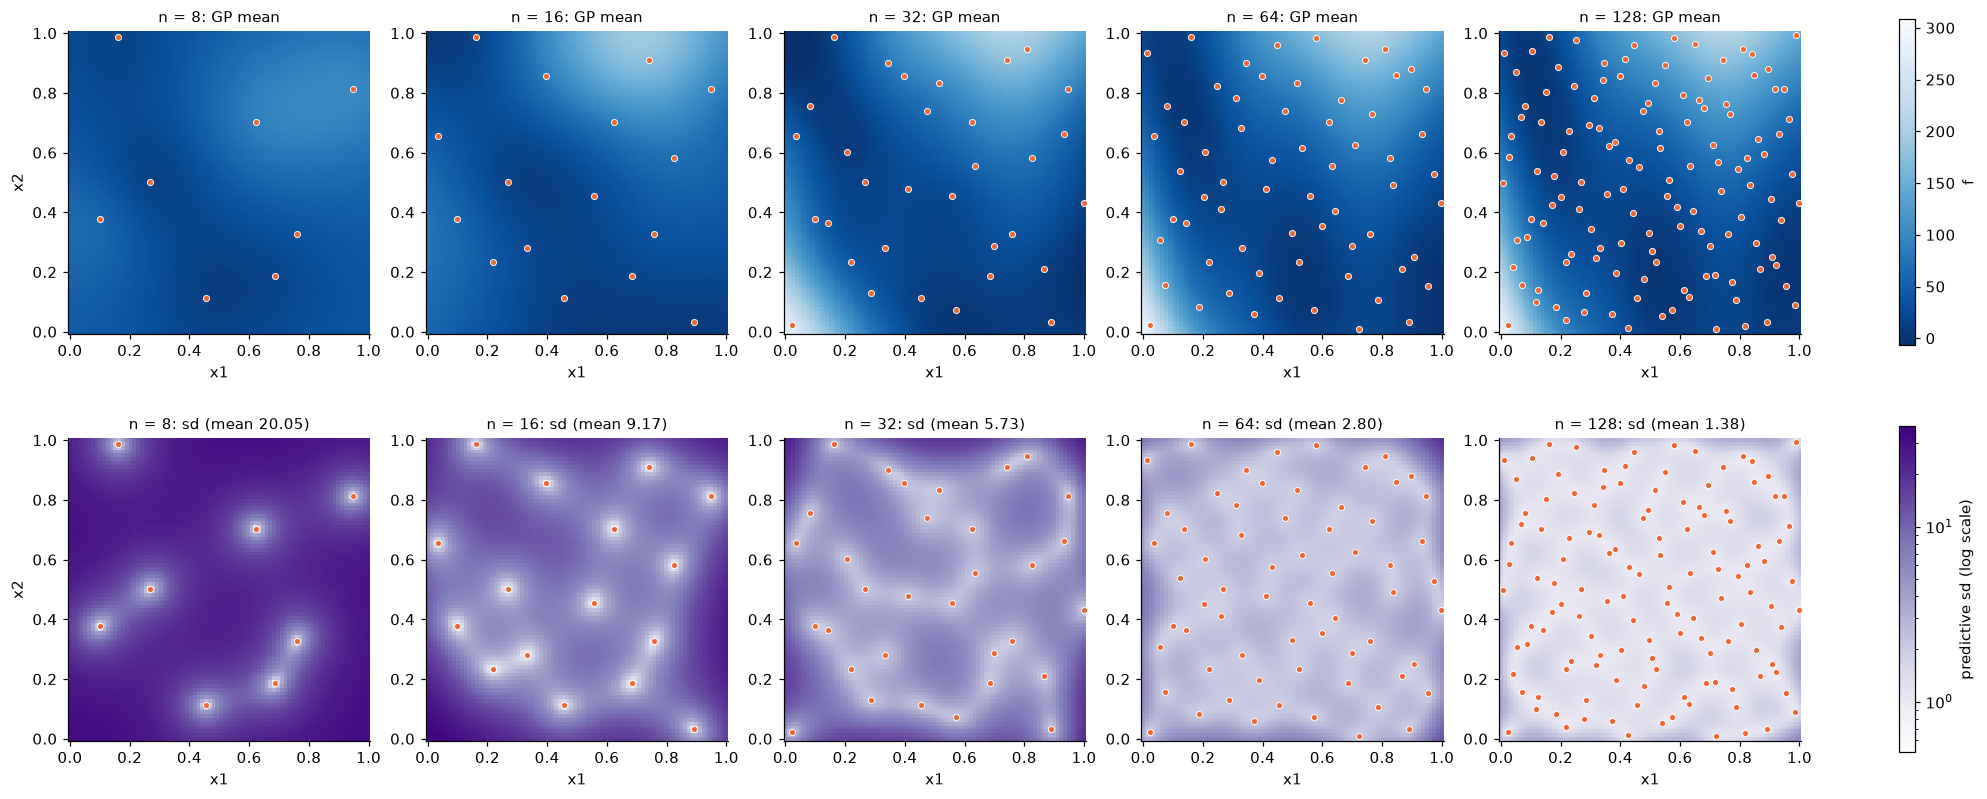

In [14]:
NS_2D = [8, 16, 32, 64, 128]
X_nest = qmc.Sobol(d=2, scramble=True, seed=2).random_base2(7)      # 128 points, nested prefixes
Z_nest = branin(X_nest)
X_chk = np.random.default_rng(21).random((200, 2))                   # held-out check points
Z_chk = branin(X_chk)

fits_2d = {}
for n in NS_2D:
    gpn = fit(X_nest[:n], Z_nest[:n], kernel="matern52")
    fits_2d[n] = {"gp": gpn, "grid": predict(gpn, X_plot), "chk": predict(gpn, X_chk)}

sd_norm = LogNorm(vmin=min(f["grid"]["sd"].min() for f in fits_2d.values()) * 1.0001 + 1e-3,
                  vmax=max(f["grid"]["sd"].max() for f in fits_2d.values()))
fig, axes = plt.subplots(2, len(NS_2D), figsize=(18, 7.4), constrained_layout=True)
for j, n in enumerate(NS_2D):
    pg_ = fits_2d[n]["grid"]
    im0 = map_panel(axes[0, j], pg_["mean"].reshape(G1.shape), "n = {0}: GP mean".format(n),
                    "Blues_r", vnorm, X_nest[:n])
    im1 = map_panel(axes[1, j], pg_["sd"].reshape(G1.shape),
                    "n = {0}: sd (mean {1:.2f})".format(n, pg_["sd"].mean()), "Purples", sd_norm,
                    X_nest[:n])
axes[0, 0].set_ylabel("x2"); axes[1, 0].set_ylabel("x2")
fig.colorbar(im0, ax=axes[0, :], shrink=0.85, label="f")
fig.colorbar(im1, ax=axes[1, :], shrink=0.85, label="predictive sd (log scale)")
plt.show()

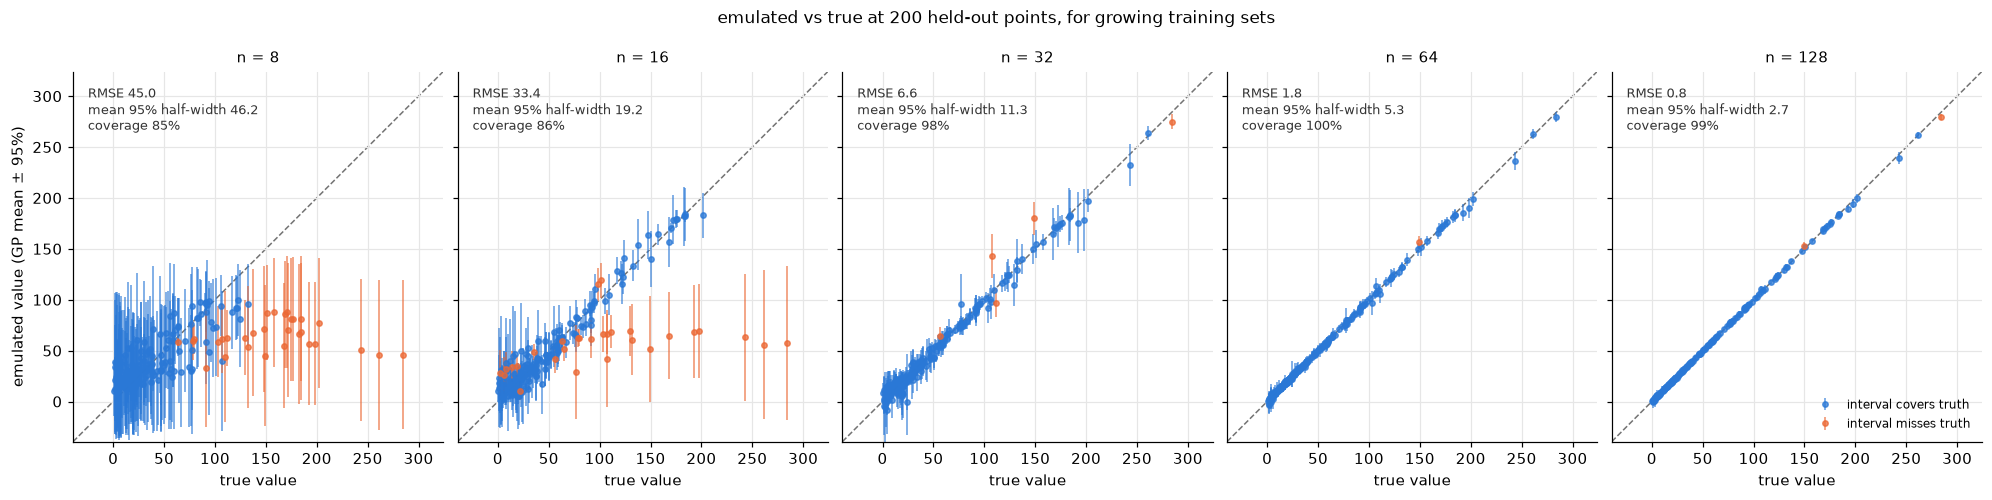

,d,RMSE,mean sd,mean 95% half-width,coverage
n,,,,,
8,0.226,45,20.1,46.2,0.85
16,0.42,33.4,9.07,19.2,0.855
32,0.643,6.59,5.53,11.3,0.975
64,0.635,1.76,2.64,5.28,0.995
128,0.528,0.75,1.35,2.66,0.99


In [15]:
lim = (Z_chk.min() - 40, Z_chk.max() + 40)
fig, axes = plt.subplots(1, len(NS_2D), figsize=(18, 4.4), sharex=True, sharey=True,
                         constrained_layout=True)
rows = []
for ax, n in zip(axes, NS_2D):
    pc = fits_2d[n]["chk"]
    hw = interval95(pc)
    miss = np.abs(pc["mean"] - Z_chk) > hw
    ax.plot(lim, lim, color="0.45", lw=1, ls="--", zorder=0)
    for sel, colr, lab in [(~miss, SERIES[0], "interval covers truth"),
                           (miss, SERIES[1], "interval misses truth")]:
        ax.errorbar(Z_chk[sel], pc["mean"][sel], yerr=hw[sel], fmt="o", ms=3.5, color=colr,
                    ecolor=colr, elinewidth=1, alpha=0.75, capsize=0, label=lab)
    rmse = np.sqrt(np.mean((pc["mean"] - Z_chk) ** 2))
    ax.text(0.04, 0.96, "RMSE {0:.1f}\nmean 95% half-width {1:.1f}\ncoverage {2:.0%}".format(
        rmse, hw.mean(), 1 - miss.mean()), transform=ax.transAxes, va="top", fontsize=8.5,
        color="0.2")
    ax.set_title("n = {0}".format(n), fontsize=10)
    ax.set_xlabel("true value")
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal")
    rows.append({"n": n, "d": fits_2d[n]["gp"].d, "RMSE": rmse, "mean sd": pc["sd"].mean(),
                 "mean 95% half-width": hw.mean(), "coverage": 1 - miss.mean()})
axes[0].set_ylabel("emulated value (GP mean ± 95%)")
axes[-1].legend(loc="lower right", fontsize=8)
fig.suptitle("emulated vs true at 200 held-out points, for growing training sets", fontsize=11)
plt.show()
with pd.option_context("display.float_format", "{:.3g}".format):
    display(pd.DataFrame(rows).set_index("n"))

Reading across the panels:

- **At n = 8** the cloud is far from the 1:1 line and the bars are long. The model knows it knows
  little.
- **As n grows**, the points close in on the line and the bars shrink with them. By n = 64 the
  emulator is nearly exact at the scale of this plot. The uncertainty falls because the
  prediction really does get better, not just because the model grows more confident.
- **Orange points** are where the stated uncertainty was too small. At n = 8 and 16 they are
  almost all high true values (above about 100). Those come from the steep corner near $(0, 0)$,
  which neither design has sampled yet (see the maps above). The GP has no data showing the
  function rises that far, so it predicts values that are too low with bars that are too short.
  Once a point lands near that corner (n = 32), the misses almost disappear. This is the
  small-design under-coverage that test C quantifies below: the sd describes uncertainty about
  the parts of the function the data have hinted at, not about features no training point has
  reached.

This figure is a single design, so its numbers move a little with the design. Tests B and C
repeat the experiment over 20 designs per size.

## 3.2 test A: fixed hyperparameters, nested designs, exact monotonicity

This takes the first $n$ points of one scrambled Sobol sequence in 2-D, for $n = 4, 5, \dots, 128$.
Prefixes of a sequence are nested by construction. The lengthscale is fixed at the value fitted
on the full 128 points, and $g = 10^{-4}$. For each $n$, the bracket term

$$v_n(x) = 1 + g - k(x)^\top K_n^{-1} k(x) = s^2_n(x)\, \frac{n}{\phi_n}$$

is recovered from the library's output (`s2 * n / gp.phi`) at all 1,600 test points. The claim is
$v_{n+1}(x) \le v_n(x)$ at every point, for every $n$ and every kernel. This is not a statistical
statement. It follows from Gaussian conditioning, so a single violation beyond round-off would
indicate a bug in the covariance or the solve.

In [16]:
X_sob = qmc.Sobol(d=2, scramble=True, seed=1).random_base2(7)    # 128 points, nested prefixes
Z_sob = branin(X_sob)
NS_A = np.arange(4, 129)
TOL_A = 1e-8

rows, v_trace = [], {}
for k in KERNELS:
    d_fix = fit(X_sob, Z_sob, kernel=k).d
    v_prev, worst, v_mean = None, -np.inf, []
    for n in NS_A:
        gpn = fit(X_sob[:n], Z_sob[:n], kernel=k, d=d_fix)
        v = gpn.predict(X_test)["s2"] * n / gpn.phi
        if v_prev is not None:
            worst = max(worst, float(np.max(v - v_prev)))
        v_prev = v
        v_mean.append(v.mean())
    v_trace[k] = np.array(v_mean)
    rows.append({"kernel": k, "fixed d": d_fix, "largest single-point increase": worst,
                 "mean v at n=4": v_mean[0], "mean v at n=128": v_mean[-1]})
    assert worst <= TOL_A, "{0}: v increased by {1:.3g} when a point was added".format(k, worst)

tab_a = pd.DataFrame(rows).set_index("kernel")
with pd.option_context("display.float_format", "{:.3g}".format):
    display(tab_a)
RESULTS.append(("A: fixed-hyperparameter variance never increases (4 kernels, n = 4..128, 1600 points)",
                "PASS", "worst increase {0:.1e} <= {1:.0e}".format(tab_a["largest single-point increase"].max(), TOL_A)))
print("test A PASS")

,fixed d,largest single-point increase,mean v at n=4,mean v at n=128
kernel,,,,
squared_exponential,0.11,2.05e-11,0.504,0.0002
matern52,0.542,2.68e-11,0.169,0.00028
matern32,1,1.9e-11,0.0732,0.000453
exponential,1.5,2e-13,0.203,0.0299


test A PASS


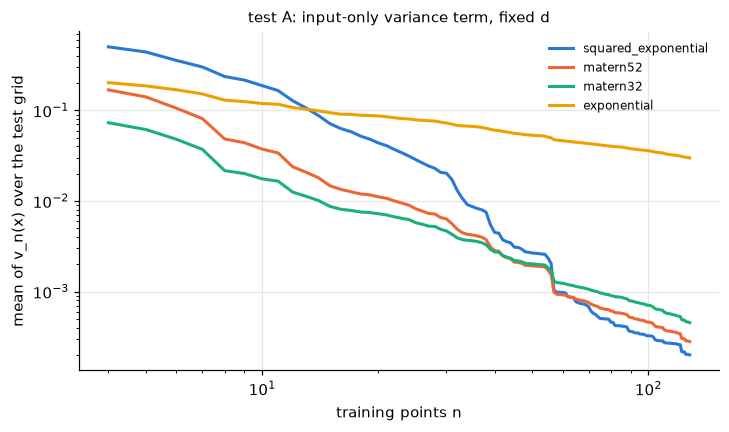

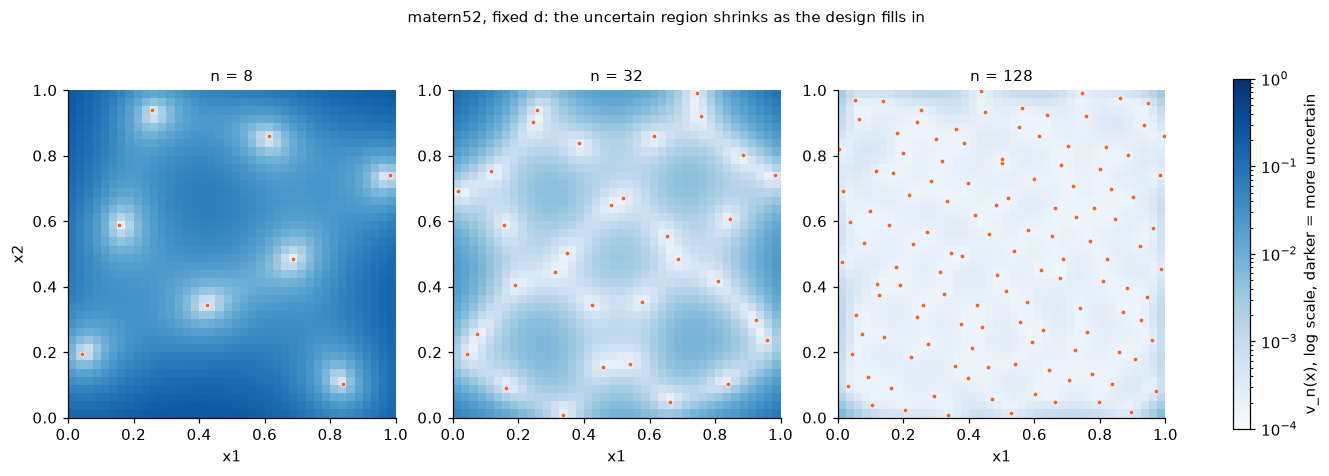

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for k in KERNELS:
    ax.loglog(NS_A, v_trace[k], label=k)
ax.set_xlabel("training points n")
ax.set_ylabel("mean of v_n(x) over the test grid")
ax.set_title("test A: input-only variance term, fixed d", fontsize=10)
ax.legend(fontsize=8)
plt.show()

# where the variance goes: the matern52 bracket term on the grid for three nested designs
k = "matern52"
d_fix = tab_a.loc[k, "fixed d"]
fig, axes = plt.subplots(1, 3, figsize=(12, 4.3), constrained_layout=True)
for ax, n in zip(axes, [8, 32, 128]):
    gpn = fit(X_sob[:n], Z_sob[:n], kernel=k, d=d_fix)
    v = (gpn.predict(X_test)["s2"] * n / gpn.phi).reshape(40, 40)
    im = ax.imshow(v, origin="lower", extent=[0, 1, 0, 1], cmap="Blues",
                   norm=LogNorm(vmin=1e-4, vmax=1))
    ax.scatter(X_sob[:n, 0], X_sob[:n, 1], s=10, color=SERIES[1], edgecolor="white", lw=0.5)
    ax.set_title("n = {0}".format(n), fontsize=10)
    ax.grid(False)
    ax.set_xlabel("x1")
axes[0].set_ylabel("x2")
fig.colorbar(im, ax=axes, shrink=0.8, label="v_n(x), log scale, darker = more uncertain")
fig.suptitle("matern52, fixed d: the uncertain region shrinks as the design fills in", fontsize=10)
plt.show()

## 3.3 test B: estimated hyperparameters, repeated random designs

In practice the lengthscale is re-estimated at every refit, and $s^2$ includes the data-dependent
factor $\phi/n$. Neither step is guaranteed to lower the variance on its own, so this test is
statistical. For each $n \in \{8, 16, \dots, 256\}$, draw 20 independent Latin hypercube designs,
fit with the defaults ($d$ estimated), and record the mean predictive sd and the RMSE over the
test grid. The claims:

1. the median, over designs, of the mean predictive sd falls at every step in $n$;
2. the median RMSE also falls at every step, so the model becomes more accurate along with more
   confident;
3. from $n = 8$ to $n = 256$, both fall by at least a factor of 10.

Squared exponential and Matérn 5/2 are both tested.

In [18]:
NS_B = [8, 16, 32, 64, 128, 256]
N_REP = 20
KERNELS_B = ["squared_exponential", "matern52"]

rec = []
t0 = time.perf_counter()
for k in KERNELS_B:
    for n in NS_B:
        for r in range(N_REP):
            Xr = qmc.LatinHypercube(d=2, seed=1000 * r + n).random(n)
            gpr_ = fit(Xr, branin(Xr), kernel=k)
            pr = predict(gpr_, X_test)
            hw = interval95(pr)
            rec.append({"kernel": k, "n": n, "rep": r, "d": gpr_.d,
                        "mean sd": pr["sd"].mean(),
                        "RMSE": np.sqrt(np.mean((pr["mean"] - Z_test) ** 2)),
                        "coverage95": np.mean(np.abs(pr["mean"] - Z_test) <= hw),
                        "mean 95% width": 2 * hw.mean()})
rec = pd.DataFrame(rec)
print("{0} fits in {1:.1f} s".format(len(rec), time.perf_counter() - t0))
summary_b = rec.groupby(["kernel", "n"])[["d", "mean sd", "RMSE", "coverage95", "mean 95% width"]].median()
with pd.option_context("display.float_format", "{:.4g}".format):
    display(summary_b)

240 fits in 9.6 s


d  mean sd   RMSE  coverage95  mean 95% width
kernel              n                                                      
matern52            8    0.1776    33.04  40.63      0.9372           152.4
                    16   0.3757    12.08  28.59      0.8869           51.22
                    32   0.5066    6.871  11.12      0.9453           27.99
                    64   0.5585    3.267  4.259      0.9897           13.05
                    128   0.487    1.567  1.836       0.985           6.203
                    256  0.4301   0.7675 0.8554      0.9897           3.023
squared_exponential 8    0.1051    25.16  35.33        0.93           116.1
                    16   0.1179    11.01  30.27      0.7934            46.7
                    32   0.1103    5.973  12.91      0.9053           24.33
                    64   0.1153     1.96  3.395      0.9841            7.83
                    128  0.1064   0.8458  1.283      0.9809           3.347
                    256 0.09437   0.4659 0.5704      0.9872           1.835

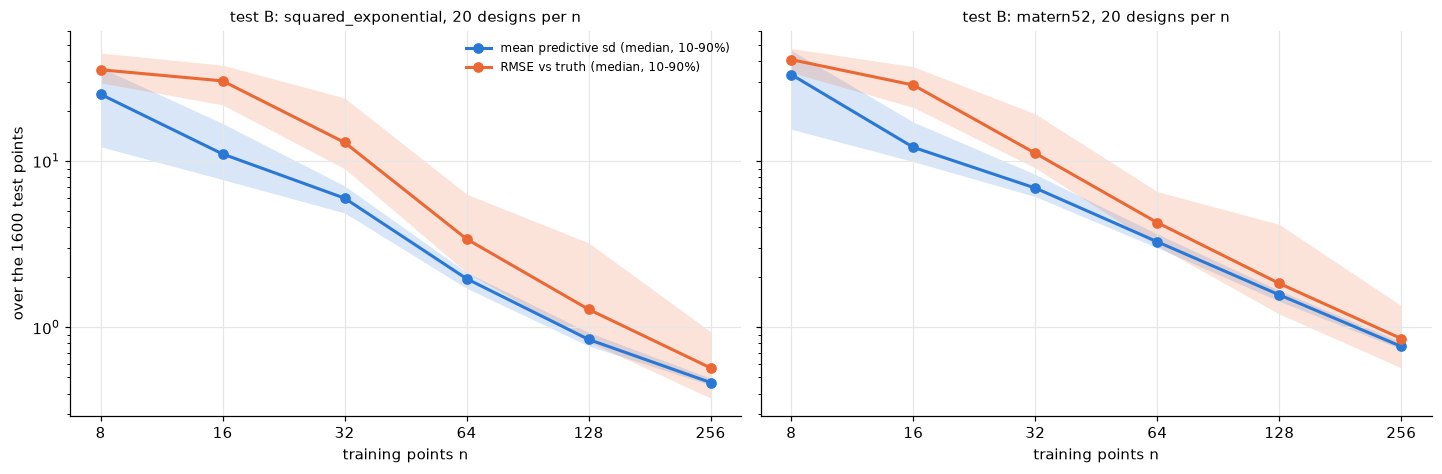

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True, constrained_layout=True)
for ax, k in zip(axes, KERNELS_B):
    sub = rec[rec.kernel == k]
    for j, (col, lab) in enumerate([("mean sd", "mean predictive sd"), ("RMSE", "RMSE vs truth")]):
        q = sub.groupby("n")[col].quantile([0.1, 0.5, 0.9]).unstack()
        ax.fill_between(q.index, q[0.1], q[0.9], color=SERIES[j], alpha=0.18, lw=0)
        ax.plot(q.index, q[0.5], "o-", color=SERIES[j], ms=6, label=lab + " (median, 10-90%)")
    ax.set_xscale("log", base=2); ax.set_yscale("log")
    ax.set_xticks(NS_B); ax.set_xticklabels(NS_B)
    ax.set_xlabel("training points n")
    ax.set_title("test B: {0}, {1} designs per n".format(k, N_REP), fontsize=10)
axes[0].set_ylabel("over the 1600 test points")
axes[0].legend(fontsize=8)
plt.show()

In [20]:
for k in KERNELS_B:
    s = summary_b.loc[k]
    sd_steps, rmse_steps = np.diff(s["mean sd"].values), np.diff(s["RMSE"].values)
    assert np.all(sd_steps < 0), "{0}: median mean sd rose between some n: {1}".format(k, s["mean sd"].values)
    assert np.all(rmse_steps < 0), "{0}: median RMSE rose between some n: {1}".format(k, s["RMSE"].values)
    sd_ratio = s["mean sd"].iloc[0] / s["mean sd"].iloc[-1]
    rmse_ratio = s["RMSE"].iloc[0] / s["RMSE"].iloc[-1]
    assert sd_ratio >= 10 and rmse_ratio >= 10, (k, sd_ratio, rmse_ratio)
    # rank correlation over all individual fits, not just the medians
    rho = spearmanr(rec[rec.kernel == k]["n"], rec[rec.kernel == k]["mean sd"])[0]
    RESULTS.append(("B: median sd and RMSE fall at every n ({0})".format(k), "PASS",
                    "sd /{0:.0f}, RMSE /{1:.0f} from n=8 to 256; Spearman(n, sd) = {2:.2f}".format(
                        sd_ratio, rmse_ratio, rho)))
    print("test B PASS  {0:20s} sd falls {1:5.1f}x, RMSE falls {2:5.1f}x, Spearman(n, sd) = {3:.2f}".format(
        k, sd_ratio, rmse_ratio, rho))

test B PASS  squared_exponential  sd falls  54.0x, RMSE falls  61.9x, Spearman(n, sd) = -0.97
test B PASS  matern52             sd falls  43.0x, RMSE falls  47.5x, Spearman(n, sd) = -0.98


## 3.4 test C: the intervals shrink and stay honest

Falling uncertainty is only useful if the stated uncertainty stays truthful. A model could shrink
its intervals and simply be wrong more often. Using the same fits as test B, this checks the
fraction of test points whose true value falls inside the 95% interval.

An interpolating GP on a deterministic function has no noise to calibrate against, so coverage
is a rough guide rather than a precise target. There are two claims:

1. once the design is dense enough to pin down the lengthscale ($n \ge 32$ here), the median
   coverage is at least 90%;
2. from $n = 8$ to $n = 256$, the median interval width falls by at least a factor of 10.

Coverage at the smallest designs is reported but not asserted. The next cell prints it.

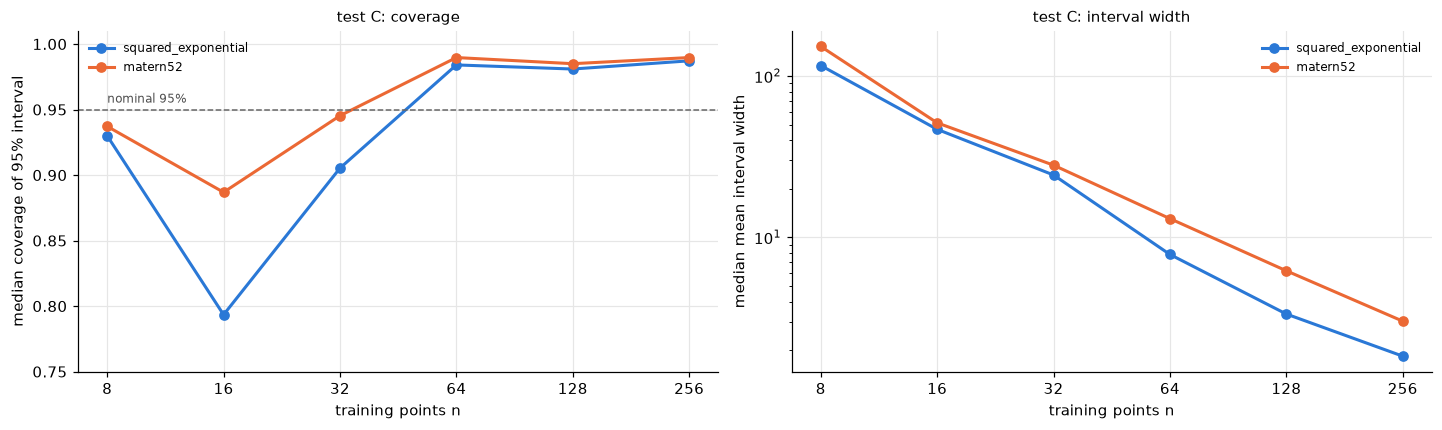

test C PASS  squared_exponential  coverage n>=32: 0.91-0.99 | n<32: 0.79-0.93 | width shrinks 63x
test C PASS  matern52             coverage n>=32: 0.95-0.99 | n<32: 0.89-0.94 | width shrinks 50x


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), constrained_layout=True)
for j, k in enumerate(KERNELS_B):
    s = summary_b.loc[k]
    axes[0].plot(s.index, s["coverage95"], "o-", color=SERIES[j], label=k)
    axes[1].plot(s.index, s["mean 95% width"], "o-", color=SERIES[j], label=k)
axes[0].axhline(0.95, color="0.4", lw=1, ls="--")
axes[0].text(NS_B[0], 0.953, "nominal 95%", fontsize=8, color="0.3", va="bottom")
axes[0].set_ylim(0.75, 1.01); axes[0].set_ylabel("median coverage of 95% interval")
axes[1].set_yscale("log"); axes[1].set_ylabel("median mean interval width")
for ax in axes:
    ax.set_xscale("log", base=2); ax.set_xticks(NS_B); ax.set_xticklabels(NS_B)
    ax.set_xlabel("training points n"); ax.legend(fontsize=8)
axes[0].set_title("test C: coverage", fontsize=10)
axes[1].set_title("test C: interval width", fontsize=10)
plt.show()

for k in KERNELS_B:
    s = summary_b.loc[k]
    dense = s.loc[s.index >= 32, "coverage95"]
    sparse = s.loc[s.index < 32, "coverage95"]
    assert dense.min() >= 0.90, (k, s["coverage95"].values)
    shrink = s["mean 95% width"].iloc[0] / s["mean 95% width"].iloc[-1]
    assert shrink >= 10, (k, shrink)
    RESULTS.append(("C: coverage >= 90% for n >= 32 while intervals shrink ({0})".format(k), "PASS",
                    "coverage {0:.2f}-{1:.2f} (n >= 32), {2:.2f}-{3:.2f} (n < 32, not asserted); width /{4:.0f}".format(
                        dense.min(), dense.max(), sparse.min(), sparse.max(), shrink)))
    print("test C PASS  {0:20s} coverage n>=32: {1:.2f}-{2:.2f} | n<32: {3:.2f}-{4:.2f} | width shrinks {5:.0f}x".format(
        k, dense.min(), dense.max(), sparse.min(), sparse.max(), shrink))

**At small $n$ the intervals can be too narrow.** With 16 points, the median coverage drops to
about 80% for the squared exponential kernel and to just under 90% for Matérn 5/2. With so few
points, the design hasn't yet sampled the steep parts of Branin, so the fitted model, meaning
both $\phi/n$ and $d$, doesn't know how much the function can vary between points. Treat the
predictive sd from a very sparse design as a rough lower bound on the uncertainty.

Coverage tends to rise above 95% at large $n$, which means the intervals are somewhat
conservative there. For a smooth deterministic function, the fitted $\phi/n$ overstates the
error left once the design is dense. Erring on that side is usually acceptable for a surrogate
used in optimisation or for choosing where to sample next.

## 3.5 test D: local approximate GP, growing the training set

For laGP, the size of each local GP is fixed by `end`. More data therefore doesn't mean a bigger
GP. It means the `end` points chosen for each prediction are closer to it. This takes nested
designs of $N$ = 250 to 8,000 points (prefixes of one Sobol sequence), with `end = 30` fixed. The
claims:

1. for both `nn` and `alc`, the mean predictive sd over 500 query points falls at every step in $N$;
2. the RMSE falls from the smallest $N$ to the largest by at least a factor of 3.

The second claim is looser than "at every step", because once the local designs are dense the
error flattens and can wobble slightly.

seconds  mean sd    RMSE
method N                             
nn     250   0.05417   0.4248  0.1778
       500   0.05309   0.3143  0.1244
       1000  0.06392   0.2443 0.08685
       2000  0.06353   0.2015 0.05224
       4000  0.06867   0.1721  0.0347
       8000  0.06119   0.1498 0.03494
alc    250   0.09631   0.5371  0.1668
       500    0.1401   0.4213  0.1085
       1000   0.2371   0.3406  0.0679
       2000   0.2424   0.2885 0.04036
       4000    0.245   0.2469 0.02957
       8000   0.2423   0.2078 0.02681

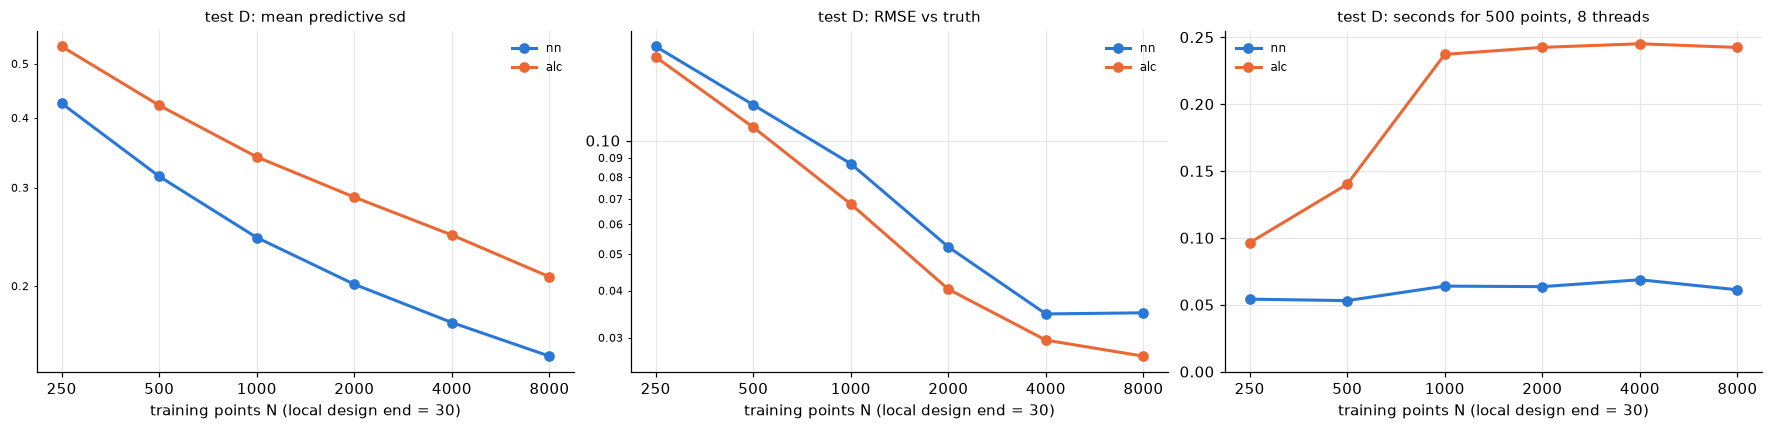

test D PASS  nn   sd falls 2.8x, RMSE falls 5.1x
test D PASS  alc  sd falls 2.6x, RMSE falls 6.2x


In [22]:
NS_D = [250, 500, 1000, 2000, 4000, 8000]
X_sd = qmc.Sobol(d=2, scramble=True, seed=7).random_base2(13)      # 8192 points, nested prefixes
rows = []
for meth in ("nn", "alc"):
    for N in NS_D:
        XN = X_sd[:N]; ZN = branin(XN); zN = ZN.mean()
        t0 = time.perf_counter()
        pl = gp_local_predict(XN, ZN - zN, X_q, start=6, end=30, method=meth, num_threads=8)
        rows.append({"method": meth, "N": N, "seconds": time.perf_counter() - t0,
                     "mean sd": np.sqrt(pl["s2"]).mean(),
                     "RMSE": np.sqrt(np.mean((pl["mean"] + zN - Z_q) ** 2))})
tab_d = pd.DataFrame(rows).set_index(["method", "N"])
with pd.option_context("display.float_format", "{:.4g}".format):
    display(tab_d)

fig, axes = plt.subplots(1, 3, figsize=(16, 3.8), constrained_layout=True)
for j, meth in enumerate(("nn", "alc")):
    s = tab_d.loc[meth]
    axes[0].loglog(s.index, s["mean sd"], "o-", color=SERIES[j], label=meth)
    axes[1].loglog(s.index, s["RMSE"], "o-", color=SERIES[j], label=meth)
    axes[2].semilogx(s.index, s["seconds"], "o-", color=SERIES[j], label=meth)
for ax, lab in zip(axes, ["mean predictive sd", "RMSE vs truth", "seconds for 500 points, 8 threads"]):
    ax.set_xticks(NS_D); ax.set_xticklabels(NS_D); ax.xaxis.set_minor_locator(NullLocator())
    if ax is not axes[2]:
        ax.yaxis.set_major_formatter(ScalarFormatter()); ax.yaxis.set_minor_formatter(ScalarFormatter())
        ax.tick_params(axis="y", which="minor", labelsize=7)
    ax.set_xlabel("training points N (local design end = 30)")
    ax.set_title("test D: " + lab, fontsize=10)
    ax.legend(fontsize=8)
axes[2].set_ylim(bottom=0)
plt.show()

for meth in ("nn", "alc"):
    s = tab_d.loc[meth]
    assert np.all(np.diff(s["mean sd"].values) < 0), (meth, s["mean sd"].values)
    rr = s["RMSE"].iloc[0] / s["RMSE"].iloc[-1]
    assert rr >= 3, (meth, rr)
    RESULTS.append(("D: laGP sd falls with N at fixed end = 30 ({0})".format(meth), "PASS",
                    "sd /{0:.1f}, RMSE /{1:.1f} from N=250 to 8000".format(
                        s["mean sd"].iloc[0] / s["mean sd"].iloc[-1], rr)))
    print("test D PASS  {0:4s} sd falls {1:.1f}x, RMSE falls {2:.1f}x".format(
        meth, s["mean sd"].iloc[0] / s["mean sd"].iloc[-1], rr))

The time per call hardly depends on $N$. For `nn` it stays flat across a 32-fold increase. For
`alc` it grows at first, while the candidate set is still small, and then levels off from about
$N$ = 1,000. That independence from $N$ is the point of the local approximation. `alc` reports a larger sd than `nn` for the same `end` and yet has the lower RMSE:
its local designs are more spread out, so it is more cautious about its own uncertainty, while
those designs also give better predictions.

## summary

In [23]:
summary = pd.DataFrame(RESULTS, columns=["test", "result", "detail"]).set_index("test")
with pd.option_context("display.max_colwidth", 120):
    display(summary)
assert (summary["result"] == "PASS").all()
print("all {0} checks passed".format(len(summary)))

,result,detail
test,,
"A: fixed-hyperparameter variance never increases (4 kernels, n = 4..128, 1600 points)",PASS,worst increase 2.7e-11 <= 1e-08
B: median sd and RMSE fall at every n (squared_exponential),PASS,"sd /54, RMSE /62 from n=8 to 256; Spearman(n, sd) = -0.97"
B: median sd and RMSE fall at every n (matern52),PASS,"sd /43, RMSE /48 from n=8 to 256; Spearman(n, sd) = -0.98"
C: coverage >= 90% for n >= 32 while intervals shrink (squared_exponential),PASS,"coverage 0.91-0.99 (n >= 32), 0.79-0.93 (n < 32, not asserted); width /63"
C: coverage >= 90% for n >= 32 while intervals shrink (matern52),PASS,"coverage 0.95-0.99 (n >= 32), 0.89-0.94 (n < 32, not asserted); width /50"
D: laGP sd falls with N at fixed end = 30 (nn),PASS,"sd /2.8, RMSE /5.1 from N=250 to 8000"
D: laGP sd falls with N at fixed end = 30 (alc),PASS,"sd /2.6, RMSE /6.2 from N=250 to 8000"


all 7 checks passed


**Summary**

- **API.** `GaussianProcess(X, Z, kernel=..., d=None, g=1e-4)` fits a model, `.predict(Xref)`
  returns `mean`, `s2` and `df`, and `gradients=True` adds `dmean`/`ds2`.
  `gp_local_predict(X, Z, Xref, start, end, method)` handles large training sets.
- **Good practice.** Centre the outputs, rescale the inputs, keep the nugget fixed for now, and
  build interval widths from the Student-t quantile with `df` degrees of freedom.
- **Uncertainty and data.** With fixed hyperparameters, adding a point never raises the
  input-only variance anywhere (test A, exact). With the usual re-estimation, uncertainty and
  error both fall steadily with $n$ (test B), the intervals stay honest while they shrink
  (test C), and laGP's uncertainty falls with the total training set even though each local GP
  stays the same size (test D).